# Model Training & Evaluation
In this phase, we establish baseline models (Random Forest vs XGBoost) and implement our Class Imbalance strategy.

In [1]:
# Run this cell to guarantee xgboost installs into the exact Python kernel your IDE is currently using
!pip install xgboost scikit-learn pandas numpy matplotlib

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# 1. Load the pristine data
X_train = pd.read_csv('../Data/final_model_data/X_train.csv')
X_test = pd.read_csv('../Data/final_model_data/X_test.csv')
y_train = pd.read_csv('../Data/final_model_data/y_train.csv').squeeze()
y_test = pd.read_csv('../Data/final_model_data/y_test.csv').squeeze()

print(f'Training Data Shape: {X_train.shape}')


Training Data Shape: (1645, 161)


### 1. Baseline: Random Forest Classifier
Implementing Class Imbalance Strategy Method A: `class_weight="balanced"`

In [3]:
# Initialize Random Forest with balanced class weights
rf_baseline = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

# Fit the model
print('Training Random Forest...')
rf_baseline.fit(X_train, y_train)

# Predict
rf_preds = rf_baseline.predict(X_test)
rf_probs = rf_baseline.predict_proba(X_test)[:, 1]

# Evaluate
print('\n=== Random Forest Baseline ===')
print(classification_report(y_test, rf_preds))
print(f'ROC-AUC Score: {roc_auc_score(y_test, rf_probs):.4f}')


Training Random Forest...

=== Random Forest Baseline ===
              precision    recall  f1-score   support

           0       0.70      0.25      0.37       127
           1       0.74      0.95      0.83       285

    accuracy                           0.74       412
   macro avg       0.72      0.60      0.60       412
weighted avg       0.73      0.74      0.69       412

ROC-AUC Score: 0.7177


### 2. Baseline: XGBoost Classifier
Implementing Class Imbalance Strategy Method A: `scale_pos_weight = count(Class 0) / count(Class 1)`

In [4]:
# Calculate scale_pos_weight
counts = y_train.value_counts()
print(f'Class Distribution in Training Set:\n{counts}')

# In this dataset, Class 1 is the MAJORITY class. Class 0 is MINORITY.
# However, in XGBoost (and most ML algorithms), 1 is treated as the "positive" class to predict.
# scale_pos_weight is multiplied against the positive class (1). 
# So scale_pos_weight = count(0) / count(1) 
scale_weight = counts[0] / counts[1]
print(f'\nXGBoost scale_pos_weight: {scale_weight:.4f}')

xgb_baseline = XGBClassifier(scale_pos_weight=scale_weight, random_state=42, n_jobs=-1, eval_metric='logloss')

# Fit the model
print('Training XGBoost...')
xgb_baseline.fit(X_train, y_train)

# Predict
xgb_preds = xgb_baseline.predict(X_test)
xgb_probs = xgb_baseline.predict_proba(X_test)[:, 1]

# Evaluate
print('\n=== XGBoost Baseline ===')
print(classification_report(y_test, xgb_preds))
print(f'ROC-AUC Score: {roc_auc_score(y_test, xgb_probs):.4f}')


Class Distribution in Training Set:
Target
1    1139
0     506
Name: count, dtype: int64

XGBoost scale_pos_weight: 0.4442
Training XGBoost...

=== XGBoost Baseline ===
              precision    recall  f1-score   support

           0       0.50      0.54      0.52       127
           1       0.79      0.76      0.77       285

    accuracy                           0.69       412
   macro avg       0.64      0.65      0.65       412
weighted avg       0.70      0.69      0.69       412

ROC-AUC Score: 0.6856


### 3. Hyperparameter Tuning (RandomizedSearchCV)
We will aggressively tune the XGBoost algorithm to maximize F1 and ROC-AUC.

In [5]:
from sklearn.model_selection import RandomizedSearchCV
import matplotlib.pyplot as plt

# Define the parameter grid to search
param_grid = {
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'scale_pos_weight': [scale_weight * 0.8, scale_weight, scale_weight * 1.2] # Slight variations around our baseline
}

# Initialize a fresh XGBoost classifier
xgb_tuner = XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss')

# We want to track both metrics, but refit the final model based on f1
scoring = {'f1': 'f1', 'roc_auc': 'roc_auc'}

# Set up RandomizedSearchCV
# n_iter=50 means we will test 50 random combinations (instead of thousands in a full grid search)
random_search = RandomizedSearchCV(
    estimator=xgb_tuner,
    param_distributions=param_grid,
    n_iter=50,
    scoring=scoring,
    refit='roc_auc', # Choose the model with the best ROC-AUC Score
    cv=5, # 5-Fold Cross Validation
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print('Running RandomizedSearchCV... This may take a minute.')
random_search.fit(X_train, y_train)

# Get the best model
best_xgb = random_search.best_estimator_

print('\nBest Parameters found:')
print(random_search.best_params_)

# Final Predict
final_preds = best_xgb.predict(X_test)
final_probs = best_xgb.predict_proba(X_test)[:, 1]

# Final Evaluate
print('\n=== TUNED XGBoost Evaluation ===')
print(classification_report(y_test, final_preds))
print(f'Final ROC-AUC Score: {roc_auc_score(y_test, final_probs):.4f}')


Running RandomizedSearchCV... This may take a minute.
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Parameters found:
{'subsample': 0.7, 'scale_pos_weight': 0.4442493415276558, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

=== TUNED XGBoost Evaluation ===
              precision    recall  f1-score   support

           0       0.45      0.61      0.52       127
           1       0.79      0.67      0.72       285

    accuracy                           0.65       412
   macro avg       0.62      0.64      0.62       412
weighted avg       0.69      0.65      0.66       412

Final ROC-AUC Score: 0.7176


### 4. Feature Importance\nVisually representing which variables are driving the model decisions.

<Figure size 1000x800 with 0 Axes>

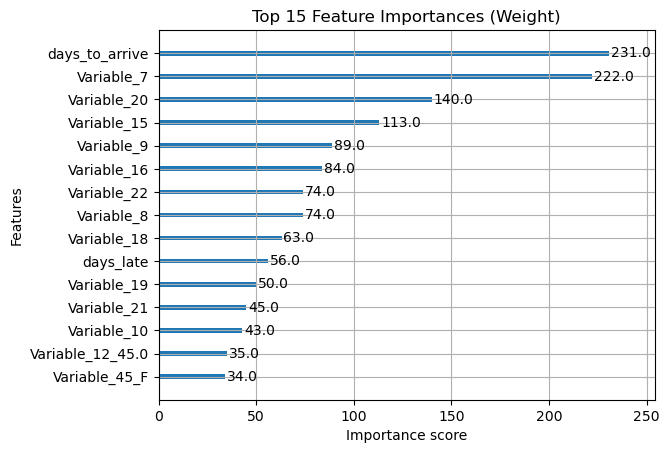

In [6]:
import xgboost as xgb
import matplotlib.pyplot as plt

# Plot top 15 most important features
plt.figure(figsize=(10, 8))
xgb.plot_importance(best_xgb, max_num_features=15, importance_type='weight', title='Top 15 Feature Importances (Weight)')
plt.savefig('../Data/feature_importance.png', bbox_inches='tight')
plt.show()


### 5. Generate Final Assignment Deliverable
We will use our tuned XGBoost model to predict the Target for the unlabelled rows (2058 to 2572) and staple the original identifiers back on for the final submission.

In [7]:
# 1. Load the pristine unlabelled data matrix we created in the Preprocessing notebook
X_pred = pd.read_csv('../Data/final_model_data/X_pred.csv')

# 2. Use our best tuned XGBoost model to make predictions
final_predictions = best_xgb.predict(X_pred)

# 3. Load the original dataset to fetch the Identifiers we dropped
original_data = pd.read_csv('../Data/cleaned_assignment_data.csv')

# The prediction rows are the ones where Target is missing (NaN)
submission_df = original_data[original_data['Target'].isna()].copy()

# 4. Attach our new predictions to the Target column
submission_df['Target'] = final_predictions

# 5. Export to CSV!
submission_df.to_csv('../Data/Final_Predictions.csv', index=False)
print(f'Successfully exported {len(submission_df)} predictions to ../Data/Final_Predictions.csv!')


Successfully exported 515 predictions to ../Data/Final_Predictions.csv!
